# Integrating ATAC and RNA sequencing data

## Learning objectives

- Load and manipulate `SummarizedExperiment` objects containing ATAC-seq and RNA-seq data.
- Understand how to categorize genomic regions based on combined accessibility (ATAC) and expression (RNA) changes.
- Annotate genomic regions with meaningful biological categories such as "Active", "Repressed", "Silent", and others.
- Use the `ComplexHeatmap` and `EnrichedHeatmap` packages to visualize multi-omics data with customizable heatmaps.
- Implement and modify heatmap functions to integrate and compare ATAC and RNA signal patterns across samples.
- Adjust factor levels to control the order of categories in heatmaps for clear biological interpretation.
- Combine multiple heatmaps and annotations for integrative visualization of chromatin accessibility and gene expression.

## Defining functional genomic states

Integrating chromatin accessibility (ATAC-seq) and gene expression (RNA-seq) data allows us to map the genome's dynamic regulatory landscape. For this course, we will use a simplified, fold-change-driven approach to categorize these **functional states**. Because our datasets were already pre-filtered for **statistical significance**, we will use basic logical conditions on the `logFC` values to assign categories. This keeps the coding pipeline straightforward while effectively illustrating the core biological concepts.

| Category                    | ATAC-seq | RNA-seq            | Biological interpretation                                                                                                                            | Analysis pipeline logic             |
| ---------------------------:|:--------:|:------------------:|:---------------------------------------------------------------------------------------------------------------------------------------------------- |:----------------------------------- |
| **Active**                  |    ↑     |          ↑         | Open chromatin and high gene expression; marks an actively transcribed gene or highly active regulatory element.                                     | `ATAC_logFC > 0 & RNA_logFC > 0`    |
| **Repressed**               |    ↓     |          ↓         | Closed chromatin and low/no gene expression; indicates a stably silenced gene or inactive regulatory element.                                        | `ATAC_logFC < 0 & RNA_logFC < 0`    |
| **Silencer Activation**     |    ↑     |          ↓         | Chromatin becomes accessible while expression drops; indicates a repressor or silencer element becoming active.                                      | `ATAC_logFC > 0 & RNA_logFC < 0`    |
| **Incongruent**             |    ↓     |          ↑         | Closed chromatin but high gene expression; suggests very efficient transcription or regulation from a highly distant active element.                 | `ATAC_logFC < 0 & RNA_logFC > 0`    |
| **Increased Accessibility** |    ↑     | `NA` (~ No change) | Chromatin becomes more accessible but expression remains unchanged; suggests a "primed" region prepared for future activation.                       | `ATAC_logFC > 0 & is.na(RNA_logFC)` |
| **Decreased Accessibility** |    ↓     | `NA` (~ No change) | Chromatin becomes less accessible but expression remains unchanged; indicates a localized regulatory shift that does not impact overall transcripts. | `ATAC_logFC < 0 & is.na(RNA_logFC)` |
_Note: More details can be found in the [comprehensive epigenetic analysis reference guide](../notes/epigenetic_analysis_reference_guide.md)._

[In our previous preparation steps](./04-genomic_overlap_matrices.ipynb), we explicitly filtered our ATAC and RNA datasets to only include features with statistically significant changes (`abs(logFC) >= .5` and `qvalue <= .1`). This pre-filtering ensures that categories requiring dual changes (like **Active** or **Repressed**) are highly robust.

However, because we removed non-significant genes prior to merging, an `NA` in our RNA column simply means a region didn't overlap a *significantly changing* gene. To keep this course module straightforward, our pipeline maps these `NA` values to the "Increased/Decreased Accessibility" categories.

This limitation also highlights the challenge of distinguishing a genuinely 'Silent' state, characterized by decreased chromatin accessibility and an absolute lack of gene expression, from a 'Repressed' state. Attempting to programmatically assign a 'Silent' category using only missing `logFC` values (`NA`) is inaccurate, as it conflates genes that are completely turned off with genes that are actively expressed but simply unchanged. For this reason, the 'Silent' category has been intentionally omitted from our simplified logic.

In a more advanced bioinformatics pipeline, we would merge the full, unfiltered datasets first. This would allow us to evaluate baseline raw counts (`baseMean`) to mathematically distinguish a genuinely **Silent** region (zero baseline transcripts) from a primed region where the gene is actively expressed but statistically unchanged.

## Initial setup and data loading

Before integrating the data, we need to load our required R packages and import the processed `SummarizedExperiment` objects and normalized matrices that we generated in previous notebooks. Because all the heavy preprocessing and signal extraction is already complete, we no longer need to load intensive data-wrangling packages, and can focus entirely on visualization and integration.

In [1]:
suppressPackageStartupMessages(suppressWarnings({
  library(SummarizedExperiment)
  library(ComplexHeatmap)
  library(EnrichedHeatmap)
  library(circlize)
  library(dplyr)  # used for case_when()
}))

### Importing processed datasets

Here we load our master `overlap` annotation object and the normalized signal matrices.

Note that we are *not* loading the genome-wide `atac_se.rds` and `rna_se.rds` `SummarizedExperiment` objects in this notebook because we are focusing entirely on visualizing the highly significant, pre-filtered regions we extracted in the [previous notebook](./04-genomic_overlap_matrices.ipynb).

As a brief reminder, here are the core steps we took previously to generate these highly refined files:

- **Master `overlap` annotation object:** Generated by mapping physical overlaps between our highly significant ATAC-seq peak regions and RNA-seq gene annotations (using our custom `metaGR()` function), seamlessly joining their statistical metadata together into a single `GRanges` object.
- **Normalized signal matrices:** Created using `normalizeToMatrix()` to extract continuous signal coverage from bigWig files across fixed genomic windows (e.g., +/- 1 kb around peak centers), formatted as mathematical grids for immediate heatmap visualization.

In [2]:
overlap <- readRDS("output/overlap_data.rds")
mat_ATAC <- readRDS("output/mat_atac.rds")
mat_RNA <- readRDS("output/mat_rna.rds")

## Categorizing genomic regions by multi-omics behavior

As we established in the biological framework during our introduction, combining ATAC-seq (chromatin accessibility) with RNA-seq (gene expression) allows us to mathematically infer the functional state of these regulatory elements. 

Using the `logFC` directions from our master `overlap` object, we will explicitly annotate every peak into one of these core biological states:

- **Active:** Both accessibility and expression increase (e.g., chromatin opening to allow transcription machinery to bind).
- **Repressed:** Accessibility increases, but expression decreases (e.g., chromatin opening specifically to allow a transcriptional *repressor* to dock).
- **Silenced:** Both accessibility and expression decrease (e.g., chromatin physically tightening to shut down a gene).
- **Incongruent:** Accessibility decreases while expression increases (often driven by complex distal interactions or alternate promoters).
- **Inc. Acc. / Dec. Acc.:** Accessibility changes, but there is no corresponding RNA-seq gene data (e.g., distant intergenic regulatory regions).

In [3]:
# Use case_when to dynamically calculate the biological state in one elegant sweep
overlap$Regulatory_State <- case_when(
  overlap$ATAC_logFC > 0 & overlap$RNA_logFC > 0  ~ "Active", 
  overlap$ATAC_logFC < 0 & overlap$RNA_logFC < 0  ~ "Silenced", 
  overlap$ATAC_logFC > 0 & overlap$RNA_logFC < 0  ~ "Repressed", 
  overlap$ATAC_logFC < 0 & overlap$RNA_logFC > 0  ~ "Incongruent", 

  # For intergenic regions where there is no matching RNA gene
  overlap$ATAC_logFC > 0 & is.na(overlap$RNA_logFC) ~ "Inc. Acc.", 
  overlap$ATAC_logFC < 0 & is.na(overlap$RNA_logFC) ~ "Dec. Acc.", 
  
  # Default fallback if anything slips through (NA is not NULL!)
  # Also note that dtype is CHAR, so it cannot be NA
  TRUE ~ NA_character_
)

saveRDS(object = overlap, file = "output/overlap_regulatory_status.rds")

In [4]:
overlap

GRanges object with 1933 ranges and 110 metadata columns:
            seqnames              ranges strand |        ATAC_annotation
               <Rle>           <IRanges>  <Rle> |            <character>
     peak_1     chr1     3670547-3672665      * |       Promoter (<=1kb)
     peak_2     chr1     4332510-4332710      * | Intron (ENSMUST00000..
     peak_3     chr1     4491755-4492573      * |       Promoter (1-2kb)
     peak_4     chr1     4571186-4572423      * |      Distal Intergenic
     peak_5     chr1     4785062-4786325      * |       Promoter (<=1kb)
        ...      ...                 ...    ... .                    ...
  peak_1929     chr2 181713633-181714134      * |       Promoter (<=1kb)
  peak_1930     chr2 181714476-181715931      * |       Promoter (<=1kb)
  peak_1931     chr2 181762779-181764180      * |       Promoter (<=1kb)
  peak_1932     chr2 181764664-181764891      * |       Promoter (1-2kb)
  peak_1933     chr2 181837244-181838655      * |       Promoter (

In [5]:
print(overlap$Regulatory_State[1:5])

[1] "Active"    "Inc. Acc." "Dec. Acc." "Dec. Acc." "Inc. Acc."


## Visualizing multi-omics integration

To visually prove the direct relationship between chromatin accessibility and gene expression, we will leverage the modular architecture we built using the `EnrichedHeatmap` and `ComplexHeatmap` packages.

Our integration strategy will follow three clear steps:

1. **The ATAC-seq Heatmap:** We will reuse our robust `make_EH_custom_na()` wrapper function (which we successfully used for our ChIP-seq and WGBS data) to plot the continuous ATAC-seq signal over our regulatory regions. Crucially, we will split the rows of this heatmap by the newly calculated `Regulatory_State` categories we just defined.
2. **The RNA-seq Heatmap:** Because RNA-seq data is discrete (a single fold-change value per gene) rather than continuous genomic coverage, we cannot use `EnrichedHeatmap`. Instead, we will construct a standard `ComplexHeatmap` block to visualize the corresponding gene expression changes.
3. **Multi-omics Assembly:** Finally, we will stitch the continuous ATAC-seq block and the discrete RNA-seq block together side-by-side. This will allow us to visually validate our biological categories (e.g., verifying that the "Active" cluster truly has high accessibility and high expression).

### Recycling our custom plotting function

To ensure our color scaling and formatting remains mathematically consistent across our entire course, we need to reuse the heatmap plotting function we perfected in previous notebooks (`custom_enrichedheatmap_plotting`).

Rather than redundantly copy-pasting this large block of code across every notebook, we have saved it into a dedicated, external R script. We can instantly load this tool into our environment using a single `source()` command.

In [6]:
# Load our custom multi-omics plotting tool from the external script
# (Note that the R kernel environment was launched from the root of the main project folder)
source("scripts/custom_enrichedheatmap_plotting.R")

> While our custom wrapper perfectly automates the most critical layout settings, there are hundreds of other parameters available to tweak almost every single pixel of our plots! If we ever need to heavily customize specific fonts, borders, grid gaps, or annotation orientations, we should explore the incredibly comprehensive [official ComplexHeatmap documentation](https://jokergoo.github.io/ComplexHeatmap-reference/book/) and [EnrichedHeatmap documentation](https://jokergoo.github.io/EnrichedHeatmap-reference/book/).

### ATAC-seq signal heatmaps

We want to stratify the E11.5 and E15.5 ATAC-seq data using our newly calculated `Regulatory_State` categories. For that, we define an annotation vector (`split_anno`) to physically split the rows of the heatmap into functional clusters, and generate a narrow, adjacent color strip (`anno_hm`) to visually label each of these distinct biological states (Active, Silenced, Repressed, etc.), just as we did previously using genomic annotation.

In [7]:
split_state <- overlap$Regulatory_State
names(split_state) <- names(overlap)

print(head(split_state))

     peak_1      peak_2      peak_3      peak_4      peak_5      peak_6 
   "Active" "Inc. Acc." "Dec. Acc." "Dec. Acc." "Inc. Acc." "Dec. Acc." 


Just as we did in the previous notebooks when we labeled our peaks by their physical location (Promoter vs. Intron) or genomic annotations (Exon, Intron, etc.), we will dynamically assign a distinct color from the `Set1` palette to each of our newly defined biological categories (Active, Silenced, Repressed, etc.).

In [8]:
# Dynamically grab enough colors from Set1 for our distinct biological states
state_names <- na.omit(sort(unique(split_state)))
anno_colors <- RColorBrewer::brewer.pal(n = length(state_names), name = "Set1")

names(anno_colors) <- state_names

> Notice that we wrap our unique categories in `na.omit()`. Because our `case_when()` logic earlier included a fallback `NA` for any peaks that didn't perfectly match our mathematical criteria, the `unique()` function would accidentally count `NA` as a distinct biological category and try to assign a color to it! `na.omit()` safely purges any missing values from the list before we build our color palette.

In [9]:
eh_state_anno <- rowAnnotation(
  df = data.frame(Regulatory_State = split_state), 
  col = list(Regulatory_State = anno_colors), 
  show_annotation_name = FALSE, 
  # show_legend = FALSE,  # Hides the stubborn right-side legend
  annotation_legend_param = list(Regulatory_State = list(title = "Regulatory State")))

When assembling complex multi-omics figures, the `ComplexHeatmap` layout engine can force row annotation legends (like our `Regulatory State` colors) to strictly follow the continuous heatmaps on the right side of the plot. If we want to physically separate them and move our categorical metadata to the bottom while keeping the continuous heatmaps on the right, we have to bypass the automatic layout engine.

To achieve this structural layout, we first disable the automatic legend generation inside our `eh_state_anno` object (by passing `show_legend = FALSE`). We then use the advanced `Legend()` function to manually reconstruct it as a standalone object (`lgd_state`), formatting it to print horizontally. We can thus inject this custom legend directly into our `draw()` function via the `annotation_legend_list` argument, giving us absolute architectural control over where it is ultimately placed.

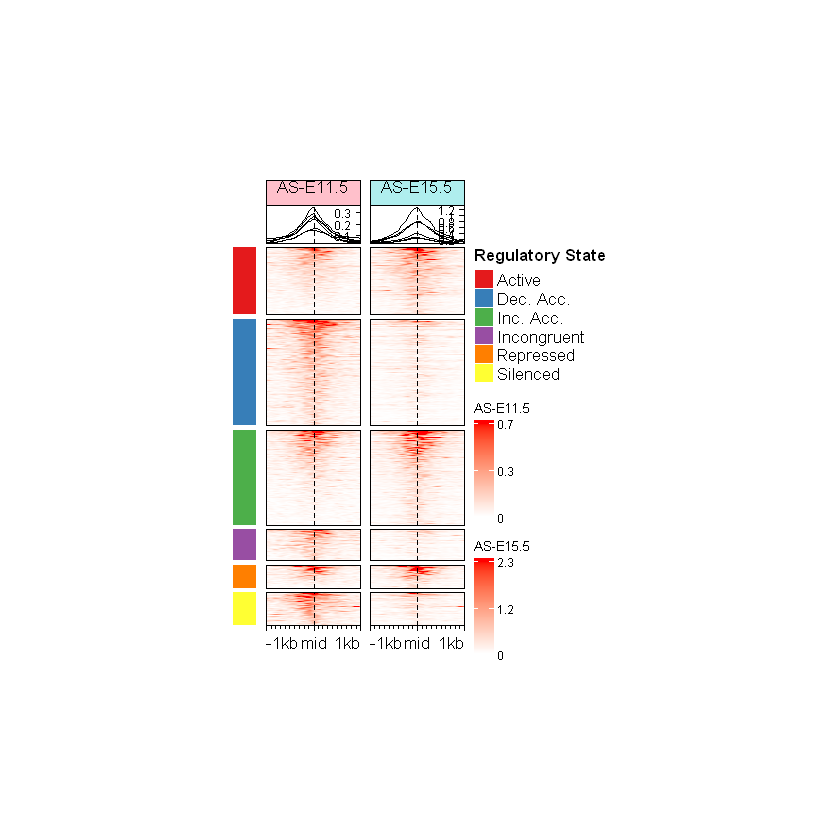

In [10]:
eh_atac_11h <- custom_enrichedheatmap_plotting(
  norm_mat = mat_ATAC[["ATAC_11half"]], 
  hm_name = "AS-E11.5", 
  hm_width = unit(2, "cm"), hm_height = unit(8, "cm"), 
  top_anno_height = unit(.8, "cm"), 
  col_fill = "pink"
)

eh_atac_15h <- custom_enrichedheatmap_plotting(
  norm_mat = mat_ATAC[["ATAC_15half"]], 
  hm_name = "AS-E15.5", 
  hm_width = unit(2, "cm"), hm_height = unit(8, "cm"), 
  top_anno_height = unit(.8, "cm"), 
  col_fill = "paleturquoise"
)

# Manually build the Regulatory State legend so we can force it to the bottom
# lgd_state <- Legend(
#   labels = names(anno_colors), 
#   legend_gp = gpar(fill = anno_colors), 
#   title = "Regulatory State", 
#   direction = "horizontal")

draw(
  eh_state_anno + eh_atac_11h + eh_atac_15h, 
  # annotation_legend_list = lgd_state, 
  split = split_state, 
)

### Interpreting ATAC-seq accessibility clusters

As expected, the categories defined by decreasing accessibility (`Dec. Acc.`, `Incongruent`, and `Silenced`) show a *clear, global loss of ATAC signal* as we transition from E11.5 to E15.5. The chromatin in these regions is physically *shutting down* during development. Conversely, the categories defined by increasing accessibility (`Active`, `Inc. Acc.`, and `Repressed`) clearly gain intensity in E15.5 (the E15.5 heatmap scales up to 2.3, whereas E11.5 only goes to 0.7).

Counter-intuitively, the raw ATAC signal in the `Dec. Acc.` cluster (at E11.5) appears significantly stronger and physically *wider* than the signal seen in the `Inc. Acc.` cluster (at E15.5). This suggests that the open regulatory regions driving early developmental states (E11.5) might exist in massive, highly accessible "super-enhancer" clusters, whereas the newly opening regions required later in development (E15.5) are much more tightly and narrowly focused. 

We often assume that regions driving active, increasing gene expression (the red `Active` cluster) would have the most blindingly intense ATAC signal. However, looking at the heatmap, the signal intensity is surprisingly moderate compared to the `Dec. Acc.` group. This confirms that a regulatory element doesn't need to be a massive, gaping hole in the chromatin to successfully drive gene expression; it only needs to be open *just enough* to let the specific transcription machinery dock.

### RNA-seq expression heatmap

Our RNA-seq data consists of discrete, normalized expression values (one mathematical value per gene, per sample). Therefore, just as we did in [Notebook 3](./03-chip_rna_visualization.ipynb), we will map this data onto a standard `ComplexHeatmap` block rather than an `EnrichedHeatmap`. To keep our analysis biologically consistent, we will continue to stratify these rows using the exact same `split_state` categories we just applied to the ATAC-seq data, allowing us to observe how gene expression behaves within each of our defined regulatory states.

In [11]:
print(colnames(mat_RNA))

[1] "RNA_11half_1" "RNA_11half_2" "RNA_15half_1" "RNA_15half_2"


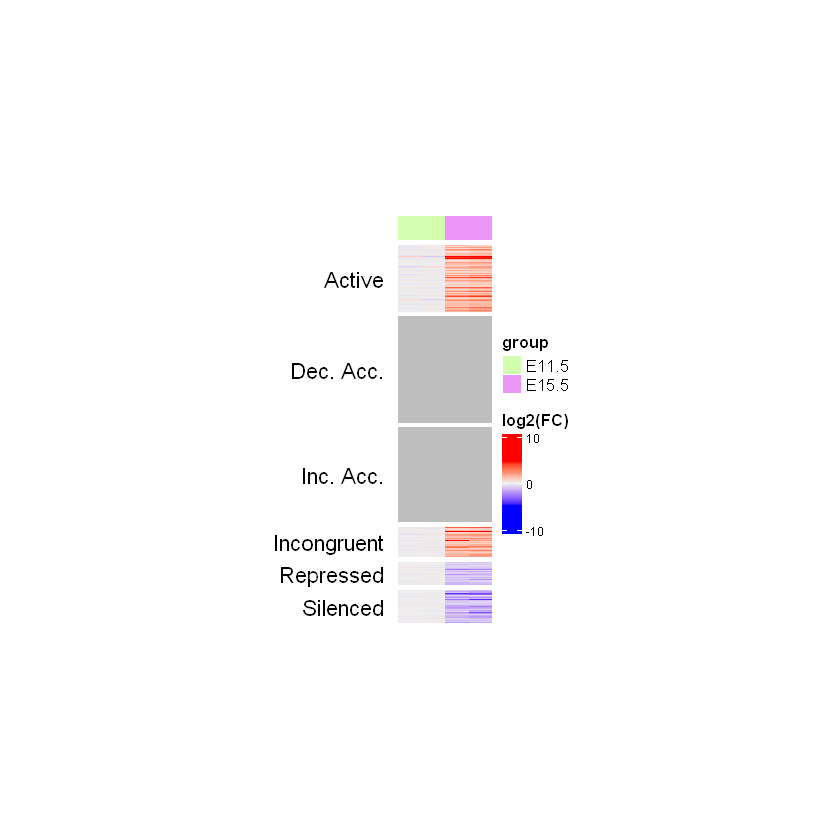

In [12]:
set.seed(100)

# Refactor/rename the RNA matrix column headers
rna_groups <- ifelse(grepl("11half", colnames(mat_RNA)), "E11.5", "E15.5")

rna_hm <- Heatmap(
  matrix = mat_RNA, 
  row_split = split_state,  # Stratify rows by biological category
  cluster_columns = FALSE, 
  cluster_rows = FALSE,  # CRITICAL: prevents clustering from crashing on NA values!
  show_row_names = FALSE, 
  show_column_names = FALSE, 
  row_title_rot = 0,  # Forces the split category labels to print horizontally
  show_row_dend = FALSE, 
  na_col = "grey",  # Grey out regions with no RNA data
  width = unit(2, "cm"), height = unit(8, "cm"), 
  top_annotation = HeatmapAnnotation(
    group = rna_groups, 
    show_annotation_name = FALSE), 
  heatmap_legend_param = list(
    at = scales::pretty_breaks(n = 2)(
      range(mat_RNA, na.rm = TRUE)),
    labels_gp = gpar(fontsize = 7), 
    title = "log2(FC)"))

draw(rna_hm, merge_legend = TRUE)

_Notice that we add `merge_legend = TRUE` to our final `draw()` command. While this parameter is typically used to deduplicate mathematically identical colorbars, it also serves as a brilliant layout trick. Because our new composite figure mixes three disparate types of legends (the main heatmap scales, a row annotation for biological state, and a column annotation for the RNA stages), the default layout algorithm will often scatter them side-by-side into different zones on the page. This command acts as a strict architectural override, forcing the engine to collect every single legend and pack them into one beautifully stacked vertical column on the right._

### RNA-seq expression patterns

Looking specifically at the RNA-seq heatmap block, we can cleanly visualize the distinct transcriptional fates of our genes during development:

1. **The Upregulated Genes (Red):**
The `Active` and `Incongruent` clusters display a striking shift from a pale E11.5 baseline to a deep red E15.5 state. This visually confirms that the genes linked to these regulatory regions are strongly upregulated and actively turning on as embryonic development progresses. 

2. **The Downregulated Genes (Blue):**
Conversely, the `Silenced` and `Repressed` clusters transition from the E11.5 baseline into a deep blue state in E15.5. This vividly demonstrates transcriptional shutdown, confirming that these specific genes are being deactivated in the later embryonic stage.

3. **The Transcriptional "Grey Zones":**
Notice that the massive `Dec. Acc.` and `Inc. Acc.` blocks are completely grey (`NA`). This perfectly visualizes our mathematical filtering: these specific categories represent dynamic regions that lack any significant corresponding gene expression data. They remain transcriptionally silent or statistically insignificant in our RNA analysis.

### Constructing the composite multi-omics heatmap

Using the `+` operator provided by `ComplexHeatmap`, we can now concatenate our colored biological annotation bar, the continuous ATAC-seq accessibility heatmaps, and the discrete RNA-seq expression heatmap into a single, highly informative composite figure.

By passing our `split_state` categories directly into the global `draw()` engine (which **overrides** individual settings), the entire composite visualization is perfectly stratified, allowing us to seamlessly validate the functional relationship between chromatin state and gene expression in a single glance.

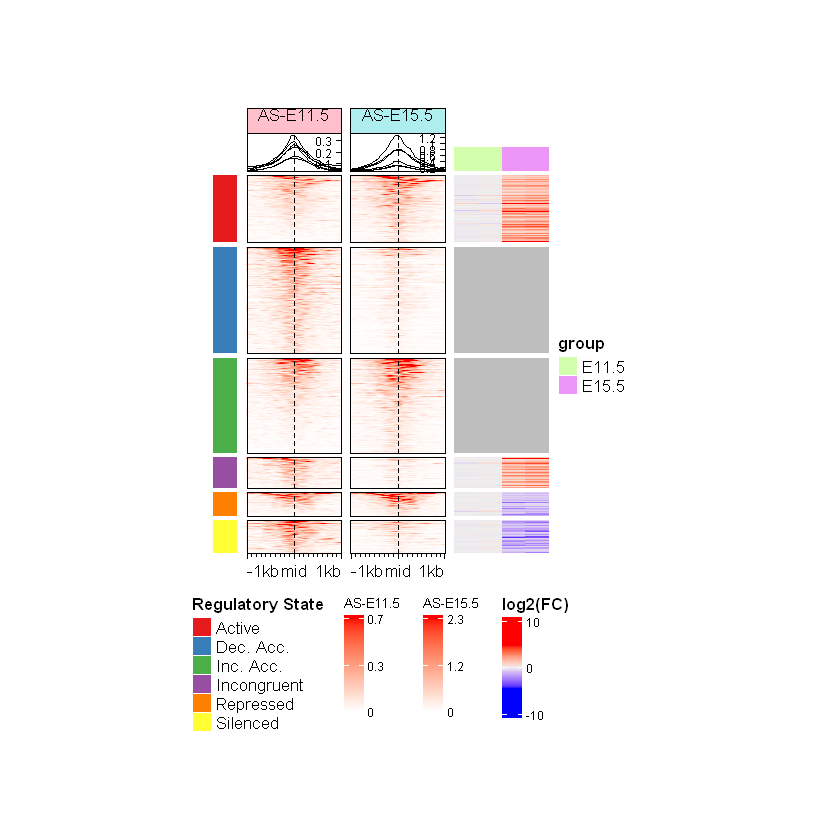

In [13]:
composite_ht <- eh_state_anno + eh_atac_11h + eh_atac_15h + rna_hm

draw(
  composite_ht, 
  split = split_state,  # global splitting
  # annotation_legend_list = lgd_state, 
  # annotation_legend_side = "right", 
  heatmap_legend_side = "bottom"
)

### Reordering biological categories

**Exercise:** Can you change the order of the heatmap regions to follow this exact biological hierarchy?
1. Active
2. Repressed
3. Silent
4. Incongruent
5. Dec. Acc.
6. Inc. Acc.

_**Hint:**_ The `split` argument in the `draw()` function automatically orders the heatmap splits based on the factor levels of the provided grouping variable (`split_anno`).

To reorder the layout, we convert our `split_state` text vector into a formal R `factor`, explicitly defining the `levels` in our exact desired biological hierarchy.

Because `ComplexHeatmap` is highly optimized, its layout engine will automatically detect these new factor levels and physically reorder the rows to match. The best part of this object-oriented design is that we **do not** need to recompute any of the heavy ATAC or RNA heatmaps! We simply re-instantiate the lightweight `eh_state_anno` color bar so it learns the new order, stitch it right back onto our existing heatmap objects, and effortlessly render the plot.


In [14]:
print(unique(split_state))

[1] "Active"      "Inc. Acc."   "Dec. Acc."   "Incongruent" "Silenced"   
[6] "Repressed"  


In [15]:
# Convert to a strict factor with the desired hierarchical order
split_state_reordered <- factor(
  split_state, 
  levels = c(
    "Active", "Repressed", "Silenced", "Incongruent", "Dec. Acc.", "Inc. Acc."))

# Re-instantiate the row annotation ONLY so it learns the new order
eh_state_anno <- rowAnnotation(
  df = data.frame(Regulatory_State = split_state_reordered), 
  col = list(Regulatory_State = anno_colors), 
  show_annotation_name = FALSE,
  annotation_legend_param = list(Regulatory_State = list(title = "Regulatory State")))

# 3Redraw the composite plot
composite_ht_2 <- eh_state_anno + eh_atac_11h + eh_atac_15h + rna_hm

### Global vsualization settings

Instead of manually tweaking the borders, title padding, and legend spacing for every single heatmap we create, `ComplexHeatmap` provides a powerful global options engine called `ht_opt`. By configuring these aesthetic rules just once per R session, they will automatically apply to every subsequent plot, guaranteeing a polished, publication-ready look with minimal code.

In [16]:
# Shrinks the empty space between the main heatmap and its title (e.g., "ATAC-E11.5")
ht_opt$TITLE_PADDING <- unit(1, "mm")

# Controls the spacing between multiple different legend boxes so they don't overlap
ht_opt$legend_gap <- unit(3, "mm")

# Shrinks the physical height of the colored squares/bars inside the legend
ht_opt$legend_grid_height <- unit(2, "mm")

# Shrinks the physical width of the colored squares/bars inside the legend
ht_opt$legend_grid_width <- unit(2, "mm")

# Squeezes the empty gap between the main heatmap body and the legend itself
ht_opt$HEATMAP_LEGEND_PADDING <- unit(1, "mm")

# Automatically draws a clean, sharp black border around every heatmap matrix!
ht_opt$heatmap_border <- TRUE

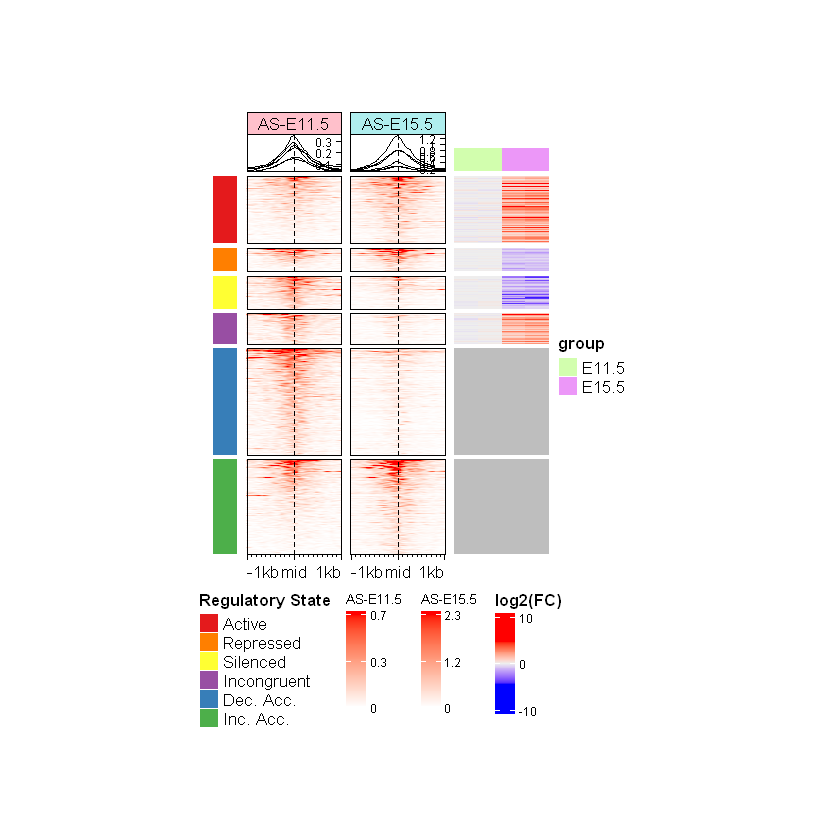

In [17]:
draw(composite_ht_2, split = split_state_reordered, heatmap_legend_side = "bottom")

### Decoding the Multi-Omics landscape

By perfectly aligning continuous chromatin accessibility (ATAC-seq) with discrete transcriptional output (RNA-seq), this composite heatmap reveals the stunning complexity of epigenetic regulation during embryonic development. We can visually validate several profound biological paradigms in a single glance:

#### The Classic Paradigms (Active & Silenced)

The **Active** (Red) and **Silenced** (Yellow) clusters clearly demonstrate the classic "central dogma" of epigenetics:
- **Active:** We see the ATAC signal physically widening and intensifying in E15.5, allowing the transcription machinery to dock. This structurally drives the massive surge in gene expression visually confirmed in the red RNA-seq block.
- **Silenced:** Conversely, we see the chromatin physically condensing and shutting down (loss of ATAC signal in E15.5), which directly results in the severe deactivation of the corresponding genes (blue RNA-seq block).

#### The Repressive Elements (Repressed)

Biology is rarely perfectly linear. In the **Repressed** (Orange) cluster, the chromatin actually *gains* massive accessibility in E15.5. However, the corresponding RNA-seq block turns deep blue, indicating the gene is strongly shut off. This visually proves that newly opened DNA is not always an activator; these specific regions are likely acting as docking sites for powerful **transcriptional repressors**.

#### The Decoupled Elements (Incongruent)

The **Incongruent** (Purple) cluster shows the exact opposite paradox: the local chromatin is physically closing down (loss of ATAC signal), yet the gene strongly turns on (red RNA). This implies that these genes are no longer dependent on this specific local element, and are likely being driven by a different, distant "super-enhancer" looping in from elsewhere in the genome.

#### The Structural DNA (Dec. Acc. & Inc. Acc.)

Finally, the massive bottom blocks represent regions undergoing massive structural changes (violent opening or closing of chromatin) without any corresponding significant gene expression (grey RNA). This perfectly illustrates a critical lesson: **chromatin accessibility does not guarantee transcription**. Many of these regions are structural elements, distant intergenic enhancers preparing for a later developmental stage, or regions driving non-coding RNAs not captured in our matrix.